# EXAA Exchange Adapter — Alpenstein Energy Portfolio

**Scenario:** Alpenstein Energy GmbH (Vienna) manages a Central European generation portfolio
and submits day-ahead bids to EXAA for the Classic auction (gate closure D-1 at 10:15 CET).

| Asset | Zone | Capacity | EXAA product type |
|-------|------|----------|-----------------|
| Reisseck II pumped-storage hydro | AT | 430 MW | Hourly (`hEXA01`–`hEXA24`) |
| Bergkamen B CCGT | DE-LU | 800 MW | Quarter-hourly (`qEXA01_1`–`qEXA24_4`) |
| AT baseload block | AT | 200 MW | Block (`bEXAbase (01-24)`) |
| AT peak block | AT | 250 MW | Block (`bEXApeak (09-20)`) |

This notebook demonstrates:
- `standard_hourly_product_id` and `standard_quarter_hourly_product_id` helpers
- Composing a mixed `ProductIdResolver` for portfolios spanning both MTU resolutions
- Writing a `BlockProductResolver` for exchange-assigned block product names
- EXAA volume sign convention: **BUY = positive, SELL = negative** (opposite of Nord Pool)
- Full `order_book_to_exaa` pipeline from `OrderBook` → submission payload
- Inspecting the wire-format JSON with `model_dump(by_alias=True)`
- Handling bid types unsupported by EXAA (`LinkedBlockBid`, `ExclusiveGroupBid`)

## Prerequisites

```bash
pip install nexa-bidkit matplotlib
# or, from source:
poetry install
```

In [1]:
from datetime import datetime, timedelta
from decimal import Decimal
import json
import zoneinfo

import matplotlib.pyplot as plt
import pandas as pd

from nexa_bidkit.bids import (
    simple_bid_from_curve,
    block_bid,
    indivisible_block_bid,
    linked_block_bid,
    SimpleBid,
    BlockBid,
    LinkedBlockBid,
)
from nexa_bidkit.curves import from_dict_list
from nexa_bidkit.orders import (
    create_order_book,
    add_bids,
    filter_bids,
    get_order_book_summary,
)
from nexa_bidkit.types import (
    BiddingZone,
    CurveType,
    DeliveryPeriod,
    Direction,
    MTUDuration,
    MTUInterval,
)
from nexa_bidkit.exaa import (
    ExaaOrderType,
    bidding_zone_to_control_area,
    order_book_to_exaa,
    simple_bid_to_exaa_product,
    standard_hourly_product_id,
    standard_quarter_hourly_product_id,
)

CET = zoneinfo.ZoneInfo("Europe/Vienna")
print("nexa-bidkit imports OK")

nexa-bidkit imports OK


## 1. Delivery Day & Timezone

EXAA operates in CET (UTC+1) / CEST (UTC+2). All product IDs (`hEXA01`, `qEXA01_1`, etc.)
are anchored to the **CET wall clock**. The standard helpers read `mtu.start.hour` directly,
so datetimes must carry the correct timezone before conversion.

In [2]:
delivery_day = datetime(2026, 3, 28, tzinfo=CET)


def mtu_hour(hour: int) -> MTUInterval:
    """1-hour MTU starting at `hour` on the delivery day."""
    return MTUInterval.from_start(
        start=delivery_day + timedelta(hours=hour),
        duration=MTUDuration.HOURLY,
    )


def mtu_quarter(hour: int, quarter: int) -> MTUInterval:
    """15-minute MTU. `quarter` ∈ {0, 1, 2, 3} maps to :00/:15/:30/:45."""
    return MTUInterval.from_start(
        start=delivery_day + timedelta(hours=hour, minutes=quarter * 15),
        duration=MTUDuration.QUARTER_HOURLY,
    )


def hourly_period(h_start: int, h_end: int) -> DeliveryPeriod:
    """Delivery period spanning whole hours (hourly resolution)."""
    return DeliveryPeriod(
        start=delivery_day + timedelta(hours=h_start),
        end=delivery_day + timedelta(hours=h_end),
        duration=MTUDuration.HOURLY,
    )


def supply(steps: list[tuple[float, float]], mtu: MTUInterval):
    """Build a SUPPLY curve from (price_eur_mwh, volume_mw) tuples."""
    return from_dict_list(
        steps=[{"price": p, "volume": v} for p, v in steps],
        curve_type=CurveType.SUPPLY,
        mtu=mtu,
    )


def demand(steps: list[tuple[float, float]], mtu: MTUInterval):
    """Build a DEMAND curve from (price_eur_mwh, volume_mw) tuples."""
    return from_dict_list(
        steps=[{"price": p, "volume": v} for p, v in steps],
        curve_type=CurveType.DEMAND,
        mtu=mtu,
    )


print(f"Delivery day:             {delivery_day.strftime('%Y-%m-%d')} (CET)")
print(f"Classic auction deadline: {(delivery_day - timedelta(days=1)).strftime('%Y-%m-%d')} 10:15 CET")
print(f"Market Coupling deadline: {(delivery_day - timedelta(days=1)).strftime('%Y-%m-%d')} 11:00 CET")

Delivery day:             2026-03-28 (CET)
Classic auction deadline: 2026-03-27 10:15 CET
Market Coupling deadline: 2026-03-27 11:00 CET


## 2. Reisseck II — Hourly Supply Bids (AT)

Reisseck II is a 430 MW pumped-storage plant in Carinthia. We submit 24 hourly supply bids
(`hEXA01`–`hEXA24`), one per hour. Each bid has a **three-step merit-order curve** reflecting
must-run generation, mid-merit dispatch, and a peak-price premium tier.

`standard_hourly_product_id(mtu)` derives the product ID directly from `mtu.start.hour`,
making it suitable whenever the auction follows the canonical EXAA naming pattern.

In [3]:
# Hourly dispatch profile: (total_mw, tier1_price, tier2_price, tier3_price)
# Water value rises with expected daily demand; prices reflect opportunity cost.
HYDRO_PROFILE = [
    (180, 12.0, 28.0,  55.0),  # H00 — off-peak
    (160, 11.0, 26.0,  52.0),  # H01
    (160, 11.0, 25.0,  50.0),  # H02 — demand trough
    (170, 12.0, 27.0,  52.0),  # H03
    (180, 13.0, 29.0,  55.0),  # H04
    (210, 15.0, 32.0,  60.0),  # H05 — morning ramp
    (270, 20.0, 42.0,  70.0),  # H06
    (340, 28.0, 54.0,  82.0),  # H07
    (400, 36.0, 64.0,  92.0),  # H08
    (430, 42.0, 72.0, 100.0),  # H09 — peak starts
    (430, 45.0, 76.0, 106.0),  # H10 — price peak
    (410, 44.0, 73.0, 102.0),  # H11
    (390, 40.0, 67.0,  94.0),  # H12 — midday dip
    (370, 38.0, 63.0,  90.0),  # H13
    (360, 37.0, 61.0,  87.0),  # H14
    (370, 38.0, 64.0,  90.0),  # H15
    (400, 41.0, 68.0,  94.0),  # H16 — afternoon ramp
    (420, 43.0, 71.0,  98.0),  # H17
    (430, 44.0, 74.0, 102.0),  # H18 — evening peak
    (420, 43.0, 72.0, 100.0),  # H19
    (370, 35.0, 60.0,  86.0),  # H20 — evening decline
    (300, 28.0, 50.0,  76.0),  # H21
    (240, 22.0, 42.0,  66.0),  # H22
    (200, 17.0, 35.0,  60.0),  # H23
]

hydro_bids = []
for hour, (total_mw, p1, p2, p3) in enumerate(HYDRO_PROFILE):
    mtu = mtu_hour(hour)
    curve = supply(
        [
            (p1, total_mw * 0.40),  # must-run / baseload tier
            (p2, total_mw * 0.40),  # mid-merit tier
            (p3, total_mw * 0.20),  # peak premium tier
        ],
        mtu,
    )
    hydro_bids.append(
        simple_bid_from_curve(
            curve=curve,
            bidding_zone=BiddingZone.AT,
            bid_id=f"reisseck-h{hour:02d}",
            metadata={"asset": "reisseck-ii", "product_id": standard_hourly_product_id(mtu)},
        )
    )

print(f"Created {len(hydro_bids)} hourly supply bids for Reisseck II (AT)")
print(f"Product IDs: {hydro_bids[0].metadata['product_id']} \u2192 {hydro_bids[-1].metadata['product_id']}")
print(f"Volume range: {min(p[0] for p in HYDRO_PROFILE)} \u2013 {max(p[0] for p in HYDRO_PROFILE)} MW/h")
print(f"Price range:  {min(p[1] for p in HYDRO_PROFILE):.0f} \u2013 {max(p[3] for p in HYDRO_PROFILE):.0f} EUR/MWh")

Created 24 hourly supply bids for Reisseck II (AT)
Product IDs: hEXA01 → hEXA24
Volume range: 160 – 430 MW/h
Price range:  11 – 106 EUR/MWh


## 3. Bergkamen B CCGT — Quarter-Hourly Bids (DE-LU)

Bergkamen B is an 800 MW combined-cycle gas plant in North Rhine-Westphalia.
After the EU MTU transition on 30 September 2025, DE-LU uses **15-minute MTUs** (96 per day).

`standard_quarter_hourly_product_id(mtu)` maps each 15-minute interval to its EXAA ID:
- 00:00–00:15 → `qEXA01_1`, 00:15–00:30 → `qEXA01_2`, …, 23:45–24:00 → `qEXA24_4`

Variable cost is derived from wholesale gas (TTF), CO₂ allowances, and thermal efficiency.

In [4]:
GAS_PRICE_EUR_MWH_TH = 29.5   # TTF wholesale gas, EUR/MWh thermal
CO2_PRICE_EUR_T = 68.0         # EU ETS carbon price
EFFICIENCY = 0.53              # thermal efficiency (~53% for CCGT)
EMISSION_FACTOR_T_PER_MWH_TH = 0.202  # t CO2 per MWh gas input

# Marginal variable cost: fuel + carbon (EUR/MWh electric)
BASE_VAR_COST = (
    GAS_PRICE_EUR_MWH_TH / EFFICIENCY
    + CO2_PRICE_EUR_T * EMISSION_FACTOR_T_PER_MWH_TH / EFFICIENCY
)


def ramp_premium(hour: int) -> float:
    """Startup cost spread across ramp-up and ramp-down hours."""
    return 5.0 if (6 <= hour <= 8 or 18 <= hour <= 20) else 0.0


ccgt_bids = []
for hour in range(24):
    for quarter in range(4):
        mtu = mtu_quarter(hour, quarter)
        marginal = round(BASE_VAR_COST + ramp_premium(hour), 2)
        curve = supply(
            [
                (marginal,       400.0),  # min stable generation
                (marginal + 4.5, 400.0),  # incremental MW (heat-rate degradation)
            ],
            mtu,
        )
        ccgt_bids.append(
            simple_bid_from_curve(
                curve=curve,
                bidding_zone=BiddingZone.DE_LU,
                bid_id=f"bergkamen-h{hour:02d}q{quarter}",
                metadata={
                    "asset": "bergkamen-b",
                    "product_id": standard_quarter_hourly_product_id(mtu),
                },
            )
        )

print(f"Created {len(ccgt_bids)} quarter-hourly supply bids for Bergkamen B (DE-LU)")
print(f"Product IDs: {ccgt_bids[0].metadata['product_id']} \u2192 {ccgt_bids[-1].metadata['product_id']}")
print(f"Base variable cost: {BASE_VAR_COST:.2f} EUR/MWh")
print(f"Ramp-hour cost:     {BASE_VAR_COST + 5.0:.2f} EUR/MWh (+startup spread)")

Created 96 quarter-hourly supply bids for Bergkamen B (DE-LU)
Product IDs: qEXA01_1 → qEXA24_4
Base variable cost: 81.58 EUR/MWh
Ramp-hour cost:     86.58 EUR/MWh (+startup spread)


## 4. Block Products — Baseload & Peak (AT)

EXAA pre-defines a fixed set of block products per auction, each with a canonical name.
Callers supply a `BlockProductResolver` — a callable mapping a `DeliveryPeriod` to the
exchange's product ID string.

Two block strategies for Reisseck II:
- **Baseload** (`bEXAbase (01-24)`): full-day water-value floor, **divisible** — EXAA can fill any portion
- **Peak** (`bEXApeak (09-20)`): extended peak commitment, **indivisible** — all-or-nothing

The `is_indivisible` property drives `fillOrKill` in the EXAA payload.

In [5]:
# EXAA block product catalogue (subset — extend as needed for your auction)
EXAA_BLOCK_PRODUCTS: dict[tuple[int, int], str] = {
    (0,  24): "bEXAbase (01-24)",      # full day
    (9,  20): "bEXApeak (09-20)",      # extended peak
    (0,   8): "bEXAoff-peak1 (01-08)", # overnight
    (20, 24): "bEXAoff-peak2 (21-24)", # late evening
    (0,  12): "bEXAam (01-12)",        # morning block
    (12, 24): "bEXApm (13-24)",        # afternoon/evening block
}


def block_product_resolver(period: DeliveryPeriod) -> str:
    """Map a delivery period's CET start/end hours to an EXAA block product ID."""
    start_cet = period.start.astimezone(CET)
    end_cet = period.end.astimezone(CET)
    start_h = start_cet.hour
    # Midnight of the following day = hour 24 in EXAA notation (01-24 = hours 1 through 24)
    end_h = end_cet.hour if end_cet.date() == start_cet.date() else 24
    key = (start_h, end_h)
    if key not in EXAA_BLOCK_PRODUCTS:
        available = list(EXAA_BLOCK_PRODUCTS.values())
        raise ValueError(
            f"No EXAA block product for hours {start_h:02d}:00 – {end_h:02d}:00. "
            f"Available: {available}"
        )
    return EXAA_BLOCK_PRODUCTS[key]


def fmt_cet(dt, *, delivery_date=None) -> str:
    """Format a CET datetime as HH:MM, showing 24:00 for end-of-day midnight."""
    cet = dt.astimezone(CET)
    if delivery_date and cet.date() > delivery_date.date() and cet.hour == 0:
        return "24:00"
    return cet.strftime("%H:%M")


# Baseload: divisible — water-value floor, exchange fills what it can
baseload_block = block_bid(
    bidding_zone=BiddingZone.AT,
    direction=Direction.SELL,
    delivery_period=hourly_period(0, 24),
    price=Decimal("30.00"),
    volume=Decimal("200"),
    min_acceptance_ratio=Decimal("0"),  # fully divisible
    bid_id="reisseck-base",
    metadata={"asset": "reisseck-ii", "strategy": "water-value-floor"},
)

# Peak: indivisible — committing full capacity or nothing
peak_block = indivisible_block_bid(
    bidding_zone=BiddingZone.AT,
    direction=Direction.SELL,
    delivery_period=hourly_period(9, 20),
    price=Decimal("58.00"),
    volume=Decimal("250"),
    bid_id="reisseck-peak",
    metadata={"asset": "reisseck-ii", "strategy": "peak-premium"},
)

for bid in (baseload_block, peak_block):
    product_id = block_product_resolver(bid.delivery_period)
    fok = "fill-or-kill" if bid.is_indivisible else "divisible"
    start_str = fmt_cet(bid.delivery_period.start, delivery_date=delivery_day)
    end_str = fmt_cet(bid.delivery_period.end, delivery_date=delivery_day)
    print(
        f"{bid.bid_id:<16}  "
        f"{start_str}\u2013{end_str} CET  "
        f"{float(bid.price):>6.2f} EUR/MWh  "
        f"{int(bid.volume):>3} MW  "
        f"[{fok}]  "
        f"\u2192 {product_id}"
    )

reisseck-base     00:00–24:00 CET   30.00 EUR/MWh  200 MW  [divisible]  → bEXAbase (01-24)
reisseck-peak     09:00–20:00 CET   58.00 EUR/MWh  250 MW  [fill-or-kill]  → bEXApeak (09-20)


## 5. Assemble the Order Book

All bids from both assets go into a single `OrderBook`. The `bidding_zone_to_control_area`
helper shows how the EXAA adapter maps each zone to its transmission system operator —
useful when verifying that your zones are supported.

In [6]:
book = create_order_book(
    metadata={
        "company": "Alpenstein Energy GmbH",
        "auction": "EXAA Classic Day-Ahead",
        "delivery_date": delivery_day.strftime("%Y-%m-%d"),
    }
)
book = add_bids(book, hydro_bids)                  # 24 hourly AT bids
book = add_bids(book, ccgt_bids)                   # 96 quarter-hourly DE-LU bids
book = add_bids(book, [baseload_block, peak_block]) # 2 AT block bids

summary = get_order_book_summary(book)
print("Order book summary:")
print(f"  Total bids: {summary['total_bids']}")
print(f"  Bid types:  {summary['bid_counts']}")
print(f"  Zones:      {summary['zones']}")

print("\nEXAA control area mapping:")
for zone_str in summary["zones"]:
    zone = BiddingZone(zone_str)
    control_area = bidding_zone_to_control_area(zone)
    print(f"  {zone.value:<6} \u2192 {control_area}")

Order book summary:
  Total bids: 122
  Bid types:  {'SIMPLE_HOURLY': 120, 'BLOCK': 2, 'LINKED_BLOCK': 0, 'EXCLUSIVE_GROUP': 0}
  Zones:      ['AT', 'DE-LU']

EXAA control area mapping:
  AT     → APG
  DE-LU  → Amprion


## 6. Convert to EXAA Submission Payload

For a portfolio mixing **hourly** (AT) and **quarter-hourly** (DE-LU) bids, a single
`ProductIdResolver` must handle both MTU durations. We compose the two standard helpers,
dispatching on `mtu.duration`.

`order_book_to_exaa` routes each bid to the correct product type container:
- `SimpleBid` + `HOURLY` → `hourlyProducts`
- `SimpleBid` + `QUARTER_HOURLY` → `15minProducts`
- `BlockBid` → `blockProducts` (via the `block_product_resolver`)

In [7]:
def product_id_resolver(mtu: MTUInterval) -> str:
    """Compose the two standard helpers, routing on MTU duration.

    EXAA ID namespaces:
        Hourly:          hEXA01 \u2013 hEXA24
        Quarter-hourly:  qEXA01_1 \u2013 qEXA24_4
    """
    if mtu.duration == MTUDuration.HOURLY:
        return standard_hourly_product_id(mtu)
    return standard_quarter_hourly_product_id(mtu)


exaa_request = order_book_to_exaa(
    order_book=book,
    account_id="APTAP1",
    product_id_resolver=product_id_resolver,
    block_product_resolver=block_product_resolver,
    order_type=ExaaOrderType.STEP,
)

account = exaa_request.orders[0]
print(f"EXAA submission \u2014 account: {account.account_id}")
print(f"  hourlyProducts   (AT):     {len(account.hourly_products.products):>3} bids  (hEXA01\u2013hEXA24)")
print(f"  blockProducts    (AT):     {len(account.block_products.products):>3} bids  (base + peak)")
print(f"  15minProducts    (DE-LU):  {len(account.fifteen_min_products.products):>3} bids  (qEXA01_1\u2013qEXA24_4)")
print(f"\n  order type:  {account.hourly_products.type_of_order.value}")
print(f"  spread order: {account.is_spread_order}")

EXAA submission — account: APTAP1
  hourlyProducts   (AT):      24 bids  (hEXA01–hEXA24)
  blockProducts    (AT):       2 bids  (base + peak)
  15minProducts    (DE-LU):   96 bids  (qEXA01_1–qEXA24_4)

  order type:  STEP
  spread order: False


## 7. Inspect the Wire-Format Payload

`model_dump(by_alias=True)` produces the camelCase JSON structure expected by
`POST /exaa-trading-api/V1/auctions/{auction-id}/orders`.

In [8]:
payload = exaa_request.model_dump(by_alias=True)

# Top-level structure
print("Top-level keys:", list(payload.keys()))
print("units:", payload["units"])
print(f"orders: {len(payload['orders'])} account order(s)")

account_payload = payload["orders"][0]
print("\nAccount order keys:", list(account_payload.keys()))

# Hourly products — show first three
hourly = account_payload["hourlyProducts"]
print(f"\nhourlyProducts — typeOfOrder: {hourly['typeOfOrder']}, count: {len(hourly['products'])}")
for p in hourly["products"][:3]:
    pairs = [(pv["price"], pv["volume"]) for pv in p["priceVolumePairs"]]
    print(f"  {p['productID']:8s}  fillOrKill={p['fillOrKill']}  pairs={pairs}")

# Block products — show all
blocks = account_payload["blockProducts"]
print(f"\nblockProducts — count: {len(blocks['products'])}")
for p in blocks["products"]:
    pv = p["priceVolumePairs"][0]
    print(
        f"  {p['productID']:<25s}  fillOrKill={p['fillOrKill']}  "
        f"price={pv['price']:.2f}  volume={pv['volume']:.1f}"
    )

# Quarter-hourly — show first two
qh = account_payload["15minProducts"]
print(f"\n15minProducts — typeOfOrder: {qh['typeOfOrder']}, count: {len(qh['products'])}")
for p in qh["products"][:2]:
    pairs = [(pv["price"], pv["volume"]) for pv in p["priceVolumePairs"]]
    print(f"  {p['productID']:14s}  fillOrKill={p['fillOrKill']}  pairs={pairs}")

# Full JSON for one representative product
print("\nFull JSON for hEXA10:")
h10 = next(p for p in hourly["products"] if p["productID"] == "hEXA10")
print(json.dumps(h10, indent=2))

Top-level keys: ['units', 'orders']
units: {'price': 'EUR', 'volume': 'MWh/h'}
orders: 1 account order(s)

Account order keys: ['accountID', 'isSpreadOrder', 'accountIDSink', 'hourlyProducts', 'blockProducts', '15minProducts']

hourlyProducts — typeOfOrder: ExaaOrderType.STEP, count: 24
  hEXA01    fillOrKill=False  pairs=[(12.0, -72.0), (28.0, -72.0), (55.0, -36.0)]
  hEXA02    fillOrKill=False  pairs=[(11.0, -64.0), (26.0, -64.0), (52.0, -32.0)]
  hEXA03    fillOrKill=False  pairs=[(11.0, -64.0), (25.0, -64.0), (50.0, -32.0)]

blockProducts — count: 2
  bEXAbase (01-24)           fillOrKill=False  price=30.00  volume=-200.0
  bEXApeak (09-20)           fillOrKill=True  price=58.00  volume=-250.0

15minProducts — typeOfOrder: ExaaOrderType.STEP, count: 96
  qEXA01_1        fillOrKill=False  pairs=[(81.58, -400.0), (86.08, -400.0)]
  qEXA01_2        fillOrKill=False  pairs=[(81.58, -400.0), (86.08, -400.0)]

Full JSON for hEXA10:
{
  "productID": "hEXA10",
  "fillOrKill": false,
  "pri

## 8. Volume Sign Convention

EXAA uses the **opposite sign convention to Nord Pool**:

| Direction | EXAA | Nord Pool |
|-----------|------|-----------|
| SELL | Negative (−) | Positive (+) |
| BUY  | Positive (+) | Negative (−) |

The adapter applies this automatically via `_signed_volume`. The assertion below confirms
the signs without running an exchange call — essential for pre-submission sanity checks.

In [9]:
# Hydro bids are SELL — volumes must be negative in the EXAA payload
h10_product = simple_bid_to_exaa_product(hydro_bids[10], standard_hourly_product_id)

print(f"Reisseck II H10 (SELL) \u2014 {standard_hourly_product_id(hydro_bids[10].curve.mtu)}:")
for pv in h10_product.price_volume_pairs:
    assert pv.volume < 0, "SELL volumes must be negative in EXAA!"
    print(f"  price={pv.price:>7.2f} EUR/MWh  \u2192  volume={pv.volume:>8.2f} MWh/h  (negative \u2713)")

# Demand-response BUY bid — volumes must be positive
dr_mtu = mtu_hour(10)
dr_curve = demand(
    [(120.0, 30.0), (85.0, 50.0)],  # price steps descending for demand
    dr_mtu,
)
dr_bid = simple_bid_from_curve(
    curve=dr_curve,
    bidding_zone=BiddingZone.AT,
    bid_id="demand-response-h10",
)
dr_product = simple_bid_to_exaa_product(dr_bid, standard_hourly_product_id)

print(f"\nDemand response H10 (BUY) \u2014 {standard_hourly_product_id(dr_mtu)}:")
for pv in dr_product.price_volume_pairs:
    assert pv.volume > 0, "BUY volumes must be positive in EXAA!"
    print(f"  price={pv.price:>7.2f} EUR/MWh  \u2192  volume=+{pv.volume:>7.2f} MWh/h  (positive \u2713)")

Reisseck II H10 (SELL) — hEXA11:
  price=  45.00 EUR/MWh  →  volume= -172.00 MWh/h  (negative ✓)
  price=  76.00 EUR/MWh  →  volume= -172.00 MWh/h  (negative ✓)
  price= 106.00 EUR/MWh  →  volume=  -86.00 MWh/h  (negative ✓)

Demand response H10 (BUY) — hEXA11:
  price= 120.00 EUR/MWh  →  volume=+  30.00 MWh/h  (positive ✓)
  price=  85.00 EUR/MWh  →  volume=+  50.00 MWh/h  (positive ✓)


## 9. Bid Types Not Supported by EXAA

EXAA does not have linked block or exclusive group concepts. Passing a `LinkedBlockBid`
or `ExclusiveGroupBid` to `order_book_to_exaa` raises a `ValueError` immediately,
rather than silently producing an incorrect payload.

The most common resolution is to filter the book before EXAA conversion, or to
model the linked relationship as an independent `BlockBid` at the combined price.

In [10]:
# EXAA rejects LinkedBlockBid and ExclusiveGroupBid with a clear ValueError.
# OrderBook validates parent references, so we include the parent bid in the demo.
parent_bid = indivisible_block_bid(
    bidding_zone=BiddingZone.AT,
    direction=Direction.SELL,
    delivery_period=hourly_period(0, 24),
    price=Decimal("30.00"),
    volume=Decimal("200"),
    bid_id="baseload-parent",
)

startup_bid = linked_block_bid(
    parent_bid_id="baseload-parent",
    bidding_zone=BiddingZone.AT,
    direction=Direction.SELL,
    delivery_period=hourly_period(0, 2),
    price=Decimal("22.00"),
    volume=Decimal("150"),
    bid_id="reisseck-startup",
)

restricted_book = add_bids(create_order_book(), [parent_bid, startup_bid])

print("Attempting EXAA export with a LinkedBlockBid...")
try:
    order_book_to_exaa(
        order_book=restricted_book,
        account_id="APTAP1",
        product_id_resolver=product_id_resolver,
        block_product_resolver=block_product_resolver,  # needed for the BlockBid parent
    )
except ValueError as e:
    print(f"  ValueError: {e}")

print()
print("Resolution: strip unsupported types before EXAA export")
print()
print("    exaa_book = filter_bids(")
print("        book, lambda bid: isinstance(bid, (SimpleBid, BlockBid))")
print("    )")

Attempting EXAA export with a LinkedBlockBid...
  ValueError: Bid 'reisseck-startup' is a LinkedBlockBid, which is not supported by EXAA. EXAA does not have a linked block concept.

Resolution: strip unsupported types before EXAA export

    exaa_book = filter_bids(
        book, lambda bid: isinstance(bid, (SimpleBid, BlockBid))
    )


## 10. Visualisations

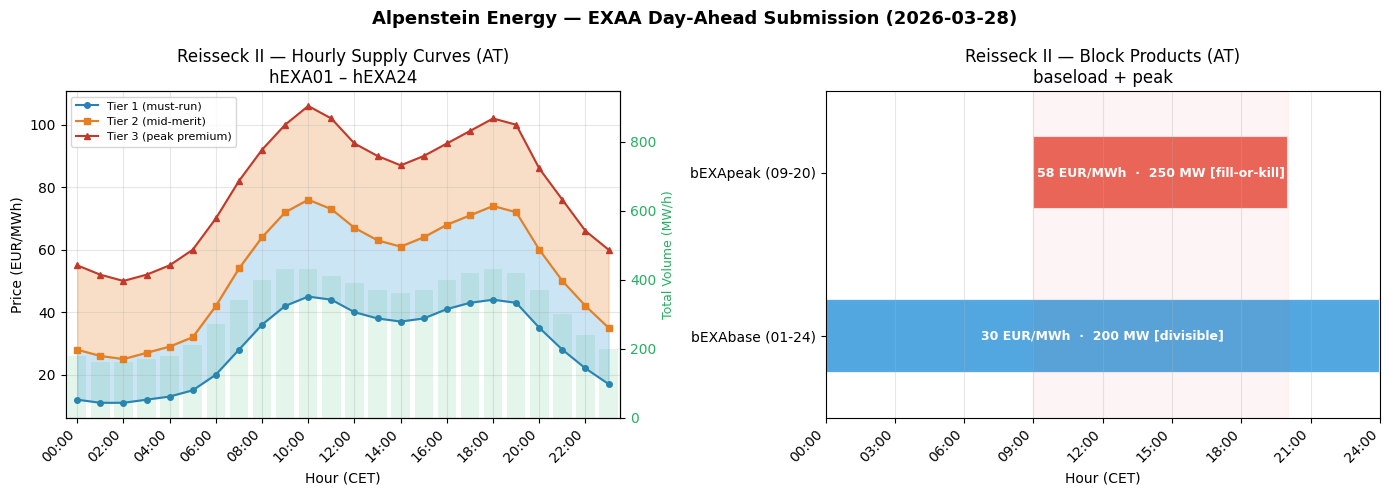

Figure saved: exaa_submission_overview.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Alpenstein Energy \u2014 EXAA Day-Ahead Submission ({delivery_day.strftime('%Y-%m-%d')})",
    fontsize=13,
    fontweight="bold",
)

# ---- Plot 1: Hydro supply curve price bands + volume profile ----
hours = list(range(24))
p1_vals = [HYDRO_PROFILE[h][1] for h in hours]
p2_vals = [HYDRO_PROFILE[h][2] for h in hours]
p3_vals = [HYDRO_PROFILE[h][3] for h in hours]
vol_vals = [HYDRO_PROFILE[h][0] for h in hours]

ax1.fill_between(hours, p1_vals, p2_vals, alpha=0.25, color="#3498db")
ax1.fill_between(hours, p2_vals, p3_vals, alpha=0.25, color="#e67e22")
ax1.plot(hours, p1_vals, "o-", color="#2980b9", markersize=4, linewidth=1.5, label="Tier 1 (must-run)")
ax1.plot(hours, p2_vals, "s-", color="#e67e22", markersize=4, linewidth=1.5, label="Tier 2 (mid-merit)")
ax1.plot(hours, p3_vals, "^-", color="#c0392b", markersize=4, linewidth=1.5, label="Tier 3 (peak premium)")

ax1_vol = ax1.twinx()
ax1_vol.bar(hours, vol_vals, alpha=0.12, color="#27ae60", width=0.8)
ax1_vol.set_ylabel("Total Volume (MW/h)", color="#27ae60", fontsize=9)
ax1_vol.tick_params(axis="y", labelcolor="#27ae60")
ax1_vol.set_ylim(0, max(vol_vals) * 2.2)

ax1.set_xlabel("Hour (CET)")
ax1.set_ylabel("Price (EUR/MWh)")
ax1.set_title("Reisseck II \u2014 Hourly Supply Curves (AT)\nhEXA01 \u2013 hEXA24")
ax1.legend(loc="upper left", fontsize=8)
ax1.set_xticks(range(0, 24, 2))
ax1.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45, ha="right")
ax1.set_xlim(-0.5, 23.5)
ax1.grid(True, alpha=0.3)

# ---- Plot 2: Block bid Gantt chart ----
block_rows = [
    ("bEXAbase (01-24)",  0,  24, 200, 30.0,  False, "#3498db"),
    ("bEXApeak (09-20)",  9,  20, 250, 58.0,  True,  "#e74c3c"),
]

for ypos, (name, h_start, h_end, vol, price, fok, color) in enumerate(block_rows):
    width = h_end - h_start
    ax2.barh(ypos, width, left=h_start, height=0.45, color=color, alpha=0.85, edgecolor="white", linewidth=1.5)
    fok_label = " [fill-or-kill]" if fok else " [divisible]"
    ax2.text(
        h_start + width / 2, ypos,
        f"{price:.0f} EUR/MWh  \u00b7  {vol} MW{fok_label}",
        ha="center", va="center", fontsize=9, fontweight="bold", color="white",
    )

ax2.set_yticks(range(len(block_rows)))
ax2.set_yticklabels([row[0] for row in block_rows])
ax2.set_xlabel("Hour (CET)")
ax2.set_title("Reisseck II \u2014 Block Products (AT)\nbaseload + peak")
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 3))
ax2.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 3)], rotation=45, ha="right")
ax2.axvspan(9, 20, alpha=0.05, color="#e74c3c", label="Peak window")
ax2.grid(True, axis="x", alpha=0.3)
ax2.set_ylim(-0.5, len(block_rows) - 0.5)

plt.tight_layout()
plt.savefig("exaa_submission_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figure saved: exaa_submission_overview.png")

## Summary

Full pipeline from bids to EXAA submission payload:

| Step | API |
|------|-----|
| Hourly product IDs | `standard_hourly_product_id(mtu)` → `"hEXA01"`–`"hEXA24"` |
| Quarter-hourly product IDs | `standard_quarter_hourly_product_id(mtu)` → `"qEXA01_1"`–`"qEXA24_4"` |
| Mixed resolver | Dispatch on `mtu.duration`, compose both helpers |
| Block product IDs | Implement `BlockProductResolver` mapping period hours → product name |
| Control area check | `bidding_zone_to_control_area(zone)` → `"APG"` / `"Amprion"` / `"TenneT"` |
| Full conversion | `order_book_to_exaa(book, account_id, product_id_resolver, block_product_resolver)` |
| Wire format | `exaa_request.model_dump(by_alias=True)` → `POST .../auctions/{id}/orders` |

**Key differences from Nord Pool:**

| | EXAA | Nord Pool |
|--|------|-----------|
| SELL volume sign | Negative (−) | Positive (+) |
| BUY volume sign | Positive (+) | Negative (−) |
| Block product IDs | Exchange-defined names | Caller-assigned |
| Linked block bids | Not supported | Supported |
| Exclusive groups | Not supported | Supported |
| Supported zones | AT, DE-LU, NL | Nordic, Baltic, PL |

**Multi-account portfolios** — if positions span multiple EXAA trade accounts,
filter the `OrderBook` per account and call `order_book_to_exaa` once per account:

```python
at_book = filter_bids(book, lambda b: b.bidding_zone == BiddingZone.AT)
nl_book = filter_bids(book, lambda b: b.bidding_zone == BiddingZone.NL)

at_request = order_book_to_exaa(at_book, account_id="APTAP1", ...)
nl_request = order_book_to_exaa(nl_book, account_id="NLTTE2", ...)
```